# CNN On Image Data

## Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

## Data Preparation

In [ ]:
train_path = '/content/drive/My Drive/lhc_dataset/dataset/train'
val_path = '/content/drive/My Drive/lhc_dataset/dataset/val'

train_file = []
val_file = []

train_file = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.h5')]
val_file = [os.path.join(val_path, f) for f in os.listdir(val_path) if f.endswith('.h5')]

print(f"Training files: {len(train_file)}, Validation files: {len(val_file)}")

Training files: 26, Validation files: 27


In [ ]:
#h5 batch generator: to save ram
def h5_batch_generator(file_list, batch_size = 32, num_classes = 5):
  while True:
    for file_path in file_list:
      with h5py.File(file_path, 'r') as f:
        images = f['jetImage'][:]
        labels = f['target'][:]

        labels = np.array([x.decode('utf-8') for x in labels])

        classes = np.unique(labels)
        label_map = {c:i for i,c in enumerate(classes)}
        labels = np.array([label_map[x] for x in labels])
        #shuffle data; to avoid bias
        idx = np.arange(len(labels))
        np.random.shuffle(idx)
        images, labels = images[idx], labels[idx]

        for i in range(0,len(labels), batch_size):
          batch_images = images[i:i+batch_size]
          batch_labels = labels[i:i+batch_size]
          #normalise to 0-1
          batch_images = batch_images.reshape(-1,100,100,1)
          batch_images = batch_images.astype('float32')/255
          yield batch_images, to_categorical(batch_labels, num_classes = num_classes)


## Model

In [ ]:
# cnn model
num_classes = 5
input_shape = (100,100,1)

model = Sequential([
    Conv2D(64,(3,3), activation='relu', kernel_initializer='he_normal', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=3e-5), loss = 'categorical_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,533,957 (13.48 MB)

 Trainable params: 3,533,317 (13.48 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
folder_path = '/content/drive/My Drive/lhc_dataset/'
checkpoint = ModelCheckpoint(folder_path + 'best_model_img.h5', save_best_only = True, monitor = 'val_loss', mode='min')
csv_log = CSVLogger(folder_path + 'training_log_img.csv', append = True)

#to prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)#reduces learning rate
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)#stops epoches

In [ ]:
#train

def total_img(file_list, dataset_name = 'jetImage'):
  total = 0
  for fpath in file_list:
    with h5py.File(fpath, 'r') as f:
      total += f[dataset_name].shape[0]
  return total

batch_size = 16
steps_per_epoch = total_img(train_file) //batch_size
validation_steps = total_img(val_file) //batch_size
train_gen = h5_batch_generator(train_file, batch_size=batch_size, num_classes=num_classes)
val_gen = h5_batch_generator(val_file, batch_size=batch_size, num_classes=num_classes)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data = val_gen,
    validation_steps = validation_steps,
    epochs = 50,
    callbacks = [checkpoint, csv_log, reduce_lr, early_stop]
)

Epoch 1/50
8124/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4818 - loss: 1.2704

8125/8125 ━━━━━━━━━━━━━━━━━━━━ 359s 43ms/step - accuracy: 0.4818 - loss: 1.2704 - val_accuracy: 0.6188 - val_loss: 0.9886 - learning_rate: 1.0000e-04
Epoch 2/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 315s 39ms/step - accuracy: 0.6112 - loss: 1.0191 - val_accuracy: 0.6504 - val_loss: 0.9950 - learning_rate: 1.0000e-04
Epoch 3/50
8124/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6520 - loss: 0.9443

8125/8125 ━━━━━━━━━━━━━━━━━━━━ 312s 38ms/step - accuracy: 0.6520 - loss: 0.9443 - val_accuracy: 0.6473 - val_loss: 0.9104 - learning_rate: 1.0000e-04
Epoch 4/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6727 - loss: 0.8997

8125/8125 ━━━━━━━━━━━━━━━━━━━━ 313s 39ms/step - accuracy: 0.6727 - loss: 0.8997 - val_accuracy: 0.6779 - val_loss: 0.8564 - learning_rate: 1.0000e-04
Epoch 5/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 309s 38ms/step - accuracy: 0.6831 - loss: 0.8755 - val_accuracy: 0.6792 - val_loss: 0.8738 - learning_rate: 1.0000e-04
Epoch 6/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 322s 40ms/step - accuracy: 0.6906 - loss: 0.8582 - val_accuracy: 0.6707 - val_loss: 0.9385 - learning_rate: 1.0000e-04
Epoch 7/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6968 - loss: 0.8444
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 309s 38ms/step - accuracy: 0.6968 - loss: 0.8444 - val_accuracy: 0.6664 - val_loss: 0.9336 - learning_rate: 1.0000e-04
Epoch 8/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 309s 38ms/step - accuracy: 0.7060 - loss: 0.8216 - val_accuracy: 0.6777 - val_loss: 0.8991 - learning_rate: 5.0000e-05
Epoch 8: early stopping
Restoring model weights from

## Evaluation

### Accuracy

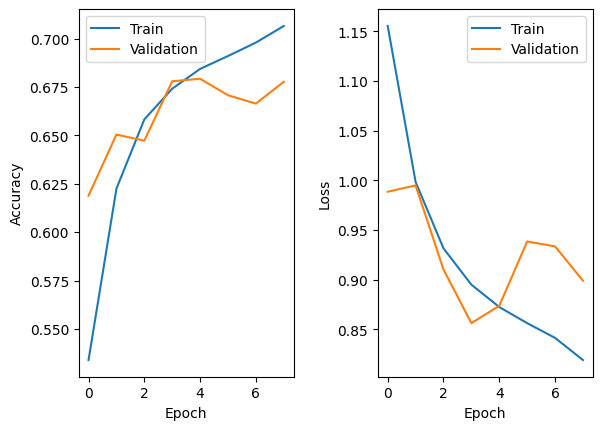

In [ ]:
 fig, axes = plt.subplots(1,2)
plt.tight_layout(pad = 3)
axes[0].plot(history.history['accuracy'])
axes[0].plot(history.history['val_accuracy'])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['Train', 'Validation'])

axes[1].plot(history.history['loss'])
axes[1].plot(history.history['val_loss'])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(['Train', 'Validation'])
plt.show()

### Visualising few Layers

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step


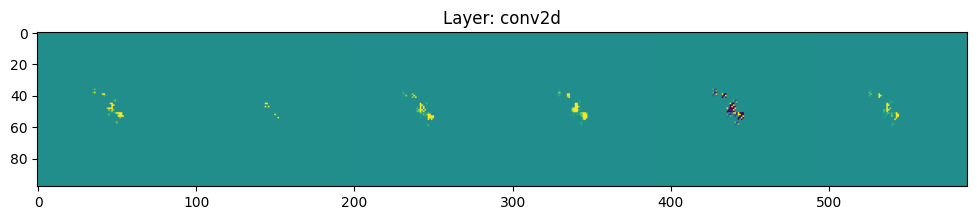

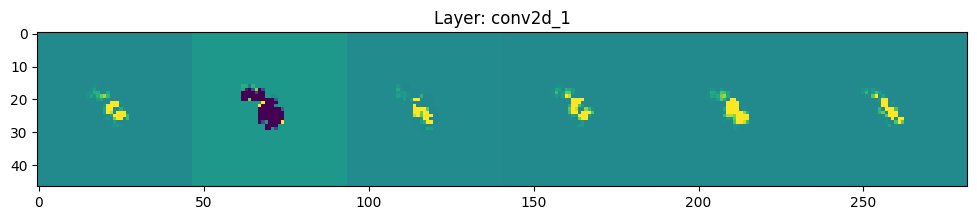

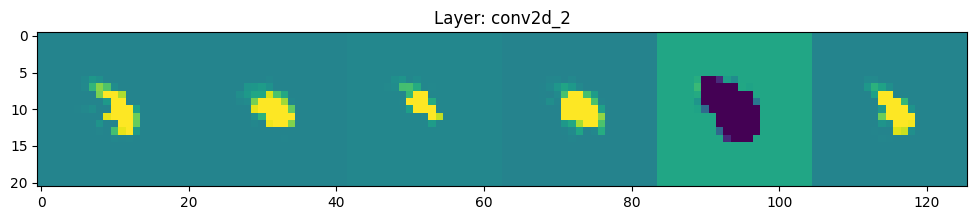

In [ ]:
with h5py.File(train_file[0], 'r') as f:
    sample_img = f['jetImage'][0]
sample_img = sample_img.reshape(1, 100, 100, 1).astype('float32') / 255.0

#outputs of all convolutional layers
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

activation_model = tf.keras.models.Model(
    inputs=model.layers[0].input,
    outputs=[layer.output for layer in model.layers if 'conv' in layer.name]
) #to prevent AttributeError: Sequential has no input

activations = activation_model.predict(sample_img)

#Visualizing first few layers
for layer_name, layer_activation in zip([layer.name for layer in model.layers if 'conv' in layer.name], activations[:3]):
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]

    n_cols = 6
    display_grid = np.zeros((size, n_cols * size))
    for col in range(n_cols):
        feature_map = layer_activation[0, :, :, col]
        feature_map -= feature_map.mean()
        feature_map /= (feature_map.std() + 1e-5)
        feature_map *= 64
        feature_map += 128
        feature_map = np.clip(feature_map, 0, 255).astype('uint8')
        display_grid[:, col * size : (col + 1) * size] = feature_map

    plt.figure(figsize=(n_cols * 2, 2))
    plt.title(f"Layer: {layer_name}")
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

### Misclassified Jets

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Total misclassified jets: 3217


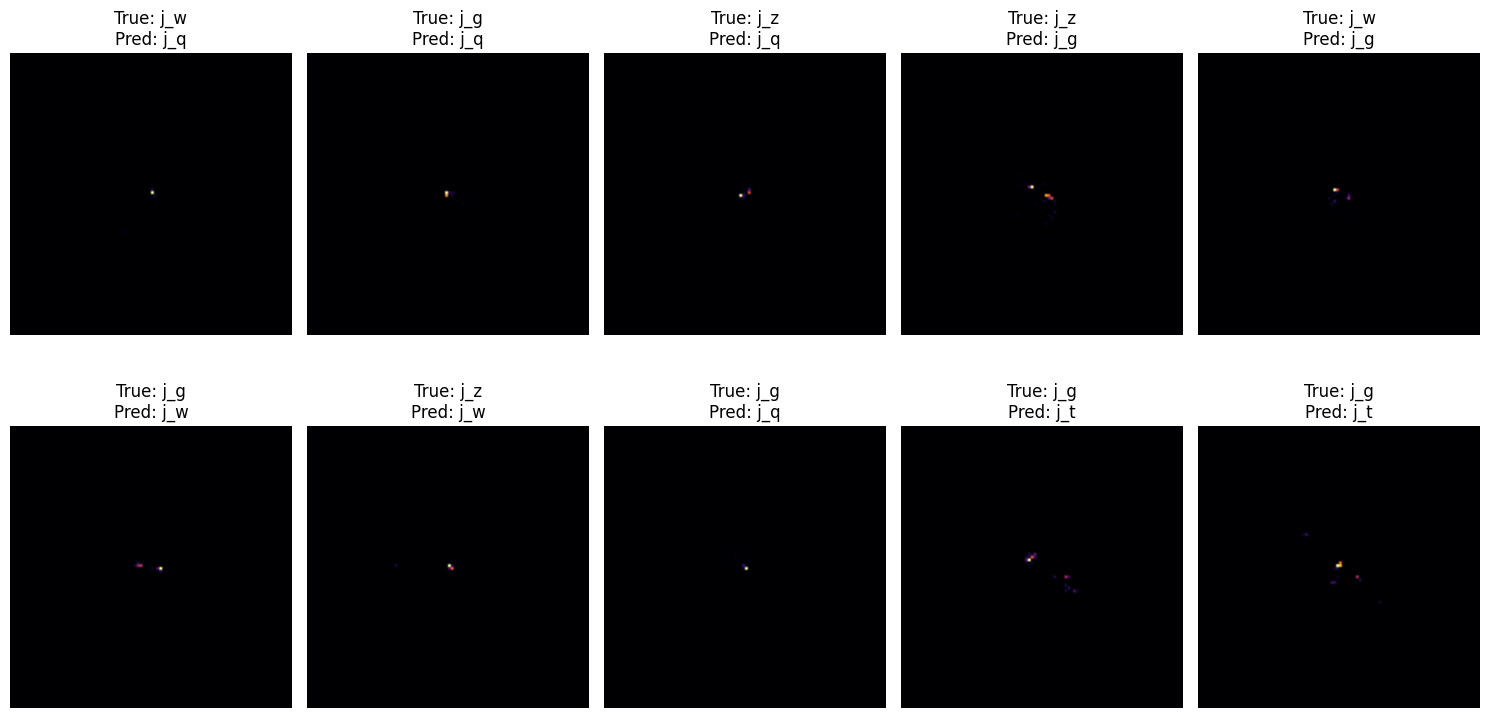

In [ ]:
model = load_model('/content/drive/My Drive/lhc_dataset/best_model_img.h5')
val_path = '/content/drive/My Drive/lhc_dataset/dataset/val/Copy of jetImage_9_30p_0_10000.h5'
with h5py.File(val_path, 'r') as f:
  x_val = f['jetImage'][:]
  y_val = f['target'][:]

y_val = np.array([label.decode('utf-8') for label in y_val])

x_val = x_val.reshape(-1, 100, 100, 1).astype('float32') / 255.0

# map class names to indices (same order as during training)
class_names = ['j_g', 'j_q', 'j_t', 'j_w', 'j_z']
y_true = np.array([class_names.index(lbl) for lbl in y_val])

#class probabilities
y_pred_probs = model.predict(x_val)
y_pred = np.argmax(y_pred_probs, axis=1)

misclassified_idx = np.where(y_pred != y_true)[0]

print(f"Total misclassified jets: {len(misclassified_idx)}")

sample_idx = misclassified_idx[:10]

plt.figure(figsize=(15, 8))
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_val[idx].reshape(100, 100), cmap='inferno')
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
y_true_mis = y_true[misclassified_idx]
y_pred_mis = y_pred[misclassified_idx]

pairs = list(zip(y_true_mis, y_pred_mis))
pair_counts = Counter(pairs)
pair_counts_dict = dict(pair_counts.items())
max_conf = None
max_mis = 0
for key in pair_counts_dict:
  if int(pair_counts_dict[key])>max_mis:
    max_mis = pair_counts_dict[key]
    max_conf = key

print(max_conf, max_mis)

(np.int64(4), np.int64(3)) 555
